# Functionalizing the SINDy-SHRED pipeline

This iPython notebook gives an introductory walkthrough to using SHRED models.  The dataset we consider is weekly mean sea-surface temperature as given by the NOAA Optimum Interpolation SST V2 dataset (https://psl.noaa.gov/data/gridded/data.noaa.oisst.v2.html).

SHRED (SHallow REcurrent Decoder) models are a network architecture that merges a recurrent layer (LSTM) with a shallow decoder network (SDN) to reconstruct high-dimensional spatio-temporal fields from a trajectory of sensor measurements of the field. More formally, the SHRED architecture can be written as 
$$ \mathcal {H} \left( \{ y_i \} _{i=t-k}^t \right) = \mathcal {F} \left( \mathcal {G} \left( \{ y_i \} _{i=t-k}^t \right) ; W_{RN}) ; W_{SD} \right)$$
where $\mathcal F$ is a feed forward network parameterized by weights $W_{SD}$, $\mathcal G$ is a LSTM network parameterized by weights $W_{RN}$, and $\{ y_i \} _{i=t-k}^t$ is a trajectory of sensor measurements of a high-dimensional spatio-temporal field $\{ x_i \} _{i=t-k}^t$.

SINDy-SHRED further extends the SHRED architecture by integrating **Sparse Identification of Nonlinear Dynamics (SINDy)** into the recurrent decoder framework. The key idea is to enforce a **parsimonious latent space representation**, where the dynamics of the latent variables are governed by a **sparse set of basis functions**. 

More formally, SINDy-SHRED introduces an additional inductive bias:

$$\dot{z} = \Theta(z) \xi$$

where:

- $z = \mathcal{G} \left( \{ y_i \} _{i=t-k}^t \right)$ represents the **latent space variables** extracted by the LSTM encoder.
- $\Theta(z)$ is a **library of candidate nonlinear functions**.
- $\xi$ is a **sparse coefficient matrix** that determines the governing equations.

This combination enables **interpretable spatio-temporal modeling** by ensuring that the learned representations adhere to a **governing law**, making the method suitable for **data-driven discovery of dynamical systems** from high-dimensional, noisy observations.

In this notebook, we will walk through the application of **SINDy-SHRED** on the **weekly mean sea-surface temperature (SST) dataset**, demonstrating how the model can **learn a reduced-order latent representation** and **recover the governing equations** that describe the SST evolution.

We first randomly select 3 sensor locations and set the trajectory length (lags) to 52, corresponding to one year of measurements.

In [1]:
import glob
import os
import random
import sys
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import driver as model_driver
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pysindy as ps

# netcdf/numpy/xray/stats
import scipy

# import plotting
import seaborn as sns
import sindy
import sindy_shred
import torch
import xarray as xr
from pydmd.mrcosts import mrCOSTS
from pydmd.phasor_notation import (
    calculate_phasor_terms,
    mode_magnitude_reorder,
    mode_reconstruction,
    mrc_phasor_components,
)
from pysindy.differentiation import FiniteDifference
from scipy.integrate import solve_ivp

warnings.filterwarnings("ignore")

# Helper functions
sys.path.append("../../../helpers")
import get_project_path

dir_helpers, dir_project, dir_data = get_project_path.project_paths()

warnings.filterwarnings("ignore")

In [2]:
def relative_error(x_est, x_true):
    """Helper function for calculating the relative error.

    :param x_est: Estimated values (i.e. from reconstruction)
    :type x_est: numpy.ndarray
    :param x_true: True (or observed) values.
    :type x_true: numpy.ndarray
    :return: Relative error between observations and model.
    :rtype: numpy.ndarray
    """
    return np.linalg.norm(x_est - x_true) / np.linalg.norm(x_true)

In [3]:
dir_hadisst_data = os.path.join(
    "/Users/karllapo/Library/CloudStorage/Dropbox/ESPRIT/proj/data/climate/HadISST/"
)
dir_print = os.path.join(
    "/Users/karllapo/Library/CloudStorage/Dropbox/ESPRIT/proj/notebooks/sindy-shred/sindy-shred/figures/HadISST"
)
dir_results = os.path.join(
    "/Users/karllapo/Dropbox/ESPRIT/proj/notebooks/mrdmd/PNAS figures/results/HadISST"
)

ds_obs = xr.open_dataset(
    os.path.join(dir_hadisst_data, "HadISST_sst.analysis-subset.nc"), engine="h5netcdf"
)
data_name = "HadISST-subset"

t1 = pd.Timestamp(ds_obs.time.values[0])
t1 = t1.replace(hour=0)
t1 = t1.replace(second=0)
t1 = t1.replace(minute=0)
t1 = t1.replace(microsecond=0)

t2 = pd.Timestamp(ds_obs.time.values[-1])
t2 = t2.replace(hour=0)
t2 = t2.replace(second=0)
t2 = t2.replace(minute=0)
t2 = t2.replace(microsecond=0)

even_time = pd.date_range(start=t1, end=t2, freq="30d")
ds_obs = ds_obs.interp(time=even_time)

# The interpolation causes the first time step to be dropped due to being out of the time bounds.
ds_obs = ds_obs.dropna(how="all", dim="time")

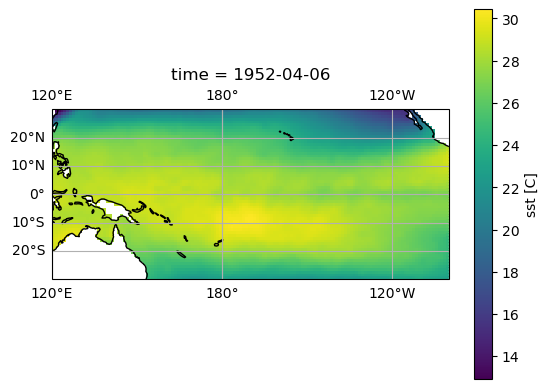

In [4]:
# define CRS's for our use case
crs0 = ccrs.PlateCarree(
    central_longitude=0
)  # for coding data, same as ccrs.PlateCarree()
crs180 = ccrs.PlateCarree(central_longitude=180)  # for plotting map in pacific area

# For all plotting, use `crs180`
fig, paco_region = plt.subplots(subplot_kw={"projection": crs180})

p = ds_obs.sst.isel(time=1000).plot(
    ax=paco_region,
    transform=crs0,  # the data's projection
)
paco_region.gridlines(crs=crs0, draw_labels=True)
paco_region.set_extent([120, 260, -30, 30], crs=crs0)
paco_region.add_feature(cfeature.COASTLINE)

In [5]:
# Get the properties of a single snapshot, specifically the portion of the data not masked by land.
data_snapshot = ds_obs.sst.isel(time=0).values
ind_lat, ind_lon = np.where(~np.isnan(data_snapshot))
n_space = len(ind_lat)
n_time = len(ds_obs.time)

longitudes_ragged = ds_obs.longitude.isel(longitude=ind_lon)
latitudes_ragged = ds_obs.latitude.isel(latitude=ind_lat)

ds_obs["sst"] = ds_obs.sst.transpose("longitude", "latitude", "time")
data_3d = ds_obs.sst.values

data_1d = data_3d.reshape(
    ds_obs.longitude.size * ds_obs.latitude.size, ds_obs.time.size
)
nandex_1d = np.nonzero(np.isnan(data_1d))
notnandex_1d = np.nonzero(~np.isnan(data_1d))

data_to_fit = data_1d[notnandex_1d]
data_to_fit = data_to_fit.reshape(n_space, n_time)

print(data_to_fit.shape)

(7815, 1854)


In [6]:
# Convert time to days
ts = ds_obs.time
ts = ts - ts.isel(time=0)
ts = (ts / (1e9 * 24 * 60 * 60)).values.astype(float)
# Time step in days
dt = 30

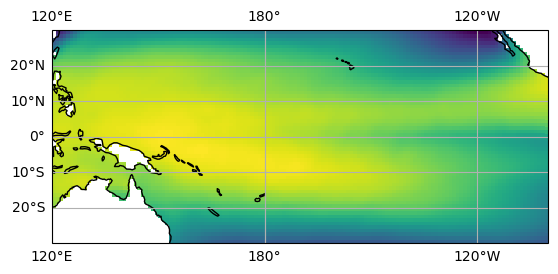

In [7]:
strategy = "svd-rank-8"
os.chdir(dir_results)
filename = ".".join([data_name, strategy])
filename = "HadISST-subset.svd-rank-8"
file_list = glob.glob(filename + "*.nc")
mrc = mrCOSTS()
mrc.from_netcdf(file_list)

mrc.multi_res_interp()
cluster_centroids, omega_classes, omega_array = mrc.global_cluster_omega(
    14, transform_method="log10"
)

# Convert the centroids to periods in units of years
cluster_centers_periods = 1 / (10 ** (cluster_centroids) / (2 * np.pi) * 365)

omega_classes_list = mrc.multi_res_deterp()
xr_sep = mrc.global_scale_reconstruction().sum(axis=0)
xr_background = mrc.get_background()

# Get the properties of a single snapshot, specifically the portion of the data not masked by land.
data_snapshot = ds_obs.sst.isel(time=0).values
ind_lon, ind_lat = np.where(~np.isnan(data_snapshot))
n_space = len(ind_lat)
n_time = len(ds_obs.time)

longitudes_ragged = ds_obs.longitude.isel(longitude=ind_lon)
latitudes_ragged = ds_obs.latitude.isel(latitude=ind_lat)

ds_background = xr.DataArray(xr_background, dims=["xy", "time"])
ds_background.coords["longitude"] = ("xy", longitudes_ragged.data)
ds_background.coords["latitude"] = ("xy", latitudes_ragged.data)
ds_background = ds_background.set_index(xy=("latitude", "longitude")).unstack("xy")

fig, paco_region = plt.subplots(subplot_kw={"projection": crs180})
plt.pcolormesh(
    ds_background.longitude.values,
    ds_background.latitude.values,
    ds_background.mean(dim="time").values,
    transform=crs0,  # the data's projection,
)

paco_region.gridlines(crs=crs0, draw_labels=True)
paco_region.set_extent([120, 260, -30, 30], crs=crs0)
paco_region.add_feature(cfeature.COASTLINE)

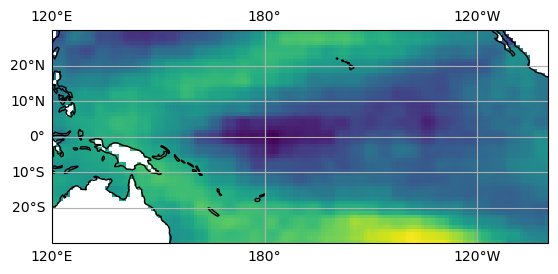

In [8]:
ds_sep = xr.DataArray(xr_sep, dims=["bands", "xy", "time"])
ds_sep.coords["longitude"] = ("xy", longitudes_ragged.data)
ds_sep.coords["latitude"] = ("xy", latitudes_ragged.data)
ds_sep.coords["bands"] = ("bands", cluster_centers_periods)
ds_sep.coords["time"] = ("time", ds_obs.time.data)
ds_sep = ds_sep.set_index(xy=("latitude", "longitude")).unstack("xy")

fig, paco_region = plt.subplots(subplot_kw={"projection": crs180})
plt.pcolormesh(
    ds_sep.longitude.values,
    ds_sep.latitude.values,
    ds_sep.isel(bands=1, time=0).values,
    transform=crs0,  # the data's projection,
)

paco_region.gridlines(crs=crs0, draw_labels=True)
paco_region.set_extent([120, 260, -30, 30], crs=crs0)
paco_region.add_feature(cfeature.COASTLINE)

In [9]:
def xarray_unstacked(x, time, longitudes, latitudes):
    """
    Unstack data back to longitude by latitude.
    """
    ds_unstacked = xr.DataArray(
        x,
        coords={"time": time},
        dims=["xy", "time"],
    )

    ds_unstacked.coords["longitude"] = ("xy", longitudes.data)
    ds_unstacked.coords["latitude"] = ("xy", latitudes.data)
    ds_unstacked = ds_unstacked.set_index(xy=("latitude", "longitude")).unstack("xy")

    return ds_unstacked


xr_global = xr_sep.sum(axis=0) + xr_background
ds_global = xarray_unstacked(
    xr_global, ds_obs.time.values, longitudes_ragged, latitudes_ragged
)

## Helpers

In [10]:
def enso_box_extract(ds, box):
    """
    Extract out data within the ENSO 3.4 box.
    """
    ds_sub = ds.where(
        (ds.latitude > box[2])
        & (ds.latitude < box[3])
        & (ds.longitude < box[1])
        & (ds.longitude > box[0]),
        drop=True,
    )

    return ds_sub


def xarray_unstacked(x, time, longitudes, latitudes):
    """
    Unstack data back to longitude by latitude.
    """
    ds_unstacked = xr.DataArray(
        x,
        coords={"time": time},
        dims=["xy", "time"],
    )

    ds_unstacked.coords["longitude"] = ("xy", longitudes.data)
    ds_unstacked.coords["latitude"] = ("xy", latitudes.data)
    ds_unstacked = ds_unstacked.set_index(xy=("latitude", "longitude")).unstack("xy")

    return ds_unstacked


def longitude_reorder(ds):
    """
    Help handle the annoying zero-line crossing that perplexes Cartopy.
    """
    ds["longitude"] = xr.where(
        ds.longitude > 0,
        ds.longitude - 180,
        ds.longitude + 180,
    )
    ds = ds.sortby(ds.longitude)
    return ds


def monthly_anomaly(ds, modern_baseline=True):
    """
    Build monthly anomalies to be consistent with the definition of ENSO3.4
    """

    if modern_baseline:
        monthly_mean = (
            ds.sel(time=slice("1991-01-01", "2020-01-01")).groupby("time.month").mean()
        )

    ds_monthly_anomaly = ds.groupby("time.month") - monthly_mean
    ds_monthly_anomaly = ds_monthly_anomaly.rolling(time=3, center=True).mean()

    return ds_monthly_anomaly


def plot_enso_box(ax, enso_box):
    """
    Plot the ENSO 3.4 box on a cartopy map.
    """
    ax.add_patch(
        mpatches.Rectangle(
            xy=[enso_box[0], enso_box[2]],
            width=50,
            height=10,
            facecolor="none",
            edgecolor="k",
            transform=crs180,
            zorder=10,
        ),
    )


def add_grid_lines(ax, no_bottom_labels=False, label_kwargs=None):
    """
    Add grid lines to a cartopy map.
    """

    if label_kwargs is None:
        label_kwargs = {"fontsize": 7}

    gl = ax.gridlines(crs=crs180, draw_labels=True)
    if not ax.axes.get_subplotspec().is_first_col():
        gl.left_labels = False
    if no_bottom_labels:
        gl.bottom_labels = False
    gl.top_labels = False
    gl.right_labels = False
    gl.xlines = False
    gl.ylines = False
    gl.xlabel_style = label_kwargs
    gl.ylabel_style = label_kwargs

    ax.set_extent([120, 260, -30, 30], crs=crs0)
    ax.add_feature(cfeature.COASTLINE)

## Build Oceanic El Nino Index (ONI)

In [11]:
enso34_box = [-170, -120, -5, 5]

ds_obs_enso = enso_box_extract(ds_obs.sst, enso34_box)
ds_reference = ds_obs_enso.sel(
    time=slice(pd.Timestamp("1991-01-01"), pd.Timestamp("2020-12-31"))
)
reference_baseline = (
    ds_reference.mean(dim=["latitude", "longitude"]).groupby("time.month").mean()
)

background_total_mean = ds_obs_enso.mean(dim=["latitude", "longitude"])
background_total_mean = (
    background_total_mean.sel(time=slice("1991-01-01", "2020-12-31"))
    .groupby("time.month")
    .mean()
)

background_spatial_mean = ds_obs_enso.mean(dim=["latitude", "longitude"]).groupby(
    "time.month"
)
background_anomaly = background_spatial_mean - background_total_mean
background_anomaly = background_anomaly.rolling(time=3, center=True).mean()

In [12]:
background_monthly = ds_obs_enso.groupby("time.month")
background_total_mean = ds_reference.mean(dim=["latitude", "longitude"])
background_total_mean = background_total_mean.groupby("time.month").mean()

ds_oni = background_monthly - background_total_mean
ds_oni = ds_oni.rolling(time=3, center=True).mean().dropna(dim="time", how="any")

In [13]:
oni_snapshot = ds_oni.isel(time=0).values
ind_lon, ind_lat = np.where(~np.isnan(oni_snapshot))
n_space_oni = len(ind_lat)
n_time_oni = len(ds_oni.time)

lon_ragged_oni = ds_oni.longitude.isel(longitude=ind_lon)
lat_ragged_oni = ds_oni.latitude.isel(latitude=ind_lat)

oni_3d = ds_oni.values

oni_1d = oni_3d.reshape(ds_oni.longitude.size * ds_oni.latitude.size, ds_oni.time.size)
nandex_1d_oni = np.nonzero(np.isnan(oni_1d))
notnandex_1d_oni = np.nonzero(~np.isnan(oni_1d))

oni_to_fit = oni_1d[notnandex_1d_oni]
oni_to_fit = oni_to_fit.reshape(n_space_oni, n_time_oni)

print(oni_to_fit.shape)

(500, 1852)


(10957.0, 18262.0)

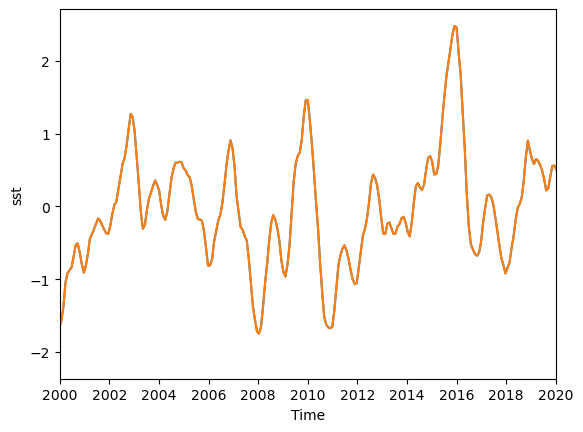

In [14]:
ds_oni.mean(dim=["longitude", "latitude"]).plot()
background_anomaly.plot()
plt.gca().set_xlim(pd.Timestamp("2000"), pd.Timestamp("2020"))

# Scale-aware SINDy-SHRED

Set random seed

In [15]:
# Set this BEFORE importing torch if you need to control GPU access
# os.environ["CUDA_VISIBLE_DEVICES"] = "2"

# Choose device
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

# Set seeds for reproducibility
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

# Optional: CUDA-specific seed (only if using CUDA)
if device == "cuda":
    torch.cuda.manual_seed(0)

# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

We now select indices to divide the data into training, validation, and test sets.

# SINDy-SHRED

## Specify data to fit

In [16]:
cluster_centers_periods

array([45.00511235, 24.90785843, 14.64321873, 11.48891573,  7.46229813,
        5.76603129,  3.74475456,  2.86423483,  1.91109242,  1.37800187,
        0.97519022,  0.70961813,  0.45783946,  0.28447929])

5.77 is extremely predictable.

7.4 year band is questionably ENSO. It does not appear to have a contribution that is measurable by ONI.

In [17]:
modes_to_fit = "ENSO"
box = "enso3.4"

# We will select a subset of the data, in this case starting in the modern period.
t_start = 120 * 12
t_start_predict = 1560  # May 1998
t_ind = slice(t_start, None)

if modes_to_fit == "original":
    lags = np.round(365 / dt).astype(int)
    scale_aware_data = data_to_fit[:, t_ind]
    num_train_years = 10
    num_test_years = 10
    num_validate_years = 0.5

elif modes_to_fit == "ONI":
    lags = 24
    scale_aware_data = oni_to_fit[:, t_ind]
    num_train_years = 10
    num_test_years = 10
    num_validate_years = 0.5

elif modes_to_fit == "annual":
    ind = np.flatnonzero(cluster_centers_periods < 1.5)
    scale_aware_data = xr_sep[ind, :, t_ind].sum(axis=0)
    lags = np.round(365 / dt).astype(int)
    num_train_years = 10
    num_test_years = 2
    num_validate_years = 1

elif modes_to_fit == "ENSO":
    num_lag_years = 2
    lags = num_lag_years * 12

    t_lim_lower = 1
    t_lim_upper = 1.4
    num_train_years = t_lim_upper * 10 + num_lag_years

    ind = np.flatnonzero(
        np.logical_and(
            cluster_centers_periods > t_lim_lower, cluster_centers_periods < t_lim_upper
        )
    )

    t_ind = slice(t_start_predict - int(num_train_years * 12), None)

    # scale_aware_data = xr_sep[ind, :, t_ind].sum(axis=0)

    # Peforming relevant indexing
    if box == "enso3.4":
        ds_scale = enso_box_extract(ds_sep.isel(bands=ind), enso34_box)
    else:
        ds_scale = ds_sep.isel(bands=ind)
    ds_scale = ds_scale.isel(time=t_ind)

    # We have to re-discover the nans for land.
    scale_snapshot = ds_scale.isel(bands=0).values.T.reshape(
        ds_scale.longitude.size * ds_scale.latitude.size, ds_scale.time.size
    )
    nandex_1d_scale = np.nonzero(np.isnan(scale_snapshot))
    notnandex_1d_scale = np.nonzero(~np.isnan(scale_snapshot))

    # Summation of bands occurs after nandexing because nans -> 0's in the summing.
    ds_scale = ds_scale.sum(dim="bands")

    scale_aware_data = ds_scale.values.T
    scale_aware_data = scale_aware_data.reshape(
        ds_scale.longitude.size * ds_scale.latitude.size, ds_scale.time.size
    )
    if not box == "enso3.4":
        scale_aware_data = scale_aware_data[notnandex_1d_scale]
        scale_aware_data = scale_aware_data.reshape(n_space, ds_scale.time.size)

    # num_train_years = 10
    num_test_years = 10
    num_validate_years = 0.1

ts_sindy_shred = ts[t_ind]
ts_physical = ds_obs.time[t_ind]

num_sensors = 500
load_X = scale_aware_data.T
len_t = load_X.shape[0]  # time dimension length
len_space = load_X.shape[1]  # space dimension length

sensor_locations = np.random.choice(len_space, size=num_sensors, replace=False)

train_length = np.round(num_train_years * 365 / dt).astype(int)
validate_length = np.round(num_validate_years * 365 / dt).astype(int)
test_length = np.round(num_test_years * 365 / dt).astype(int)

(0.0, 318.0)

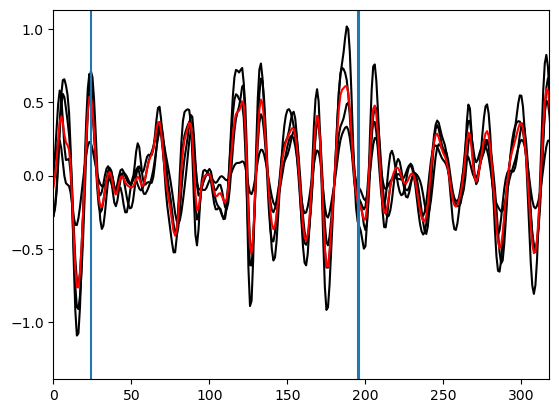

In [18]:
s = scale_aware_data.shape[0]
for n in [0, s // 4, s // 2, int(s // 4 * 3)]:
    plt.plot(scale_aware_data[n], color="k")

plt.plot(scale_aware_data.mean(axis=0), color="r")
plt.gca().axvline(train_length)
plt.gca().axvline(validate_length + train_length)
plt.gca().axvline(lags)
plt.xlim(0, train_length + validate_length + test_length)

In [62]:
ts_physical.isel(time=int(num_train_years * 12 + lags))

<xarray.DataArray 'time' ()> Size: 8B
array('2000-03-25T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2000-03-25
Attributes:
    long_name:      Time
    standard_name:  time

## Fit

In [20]:
latent_dim = 5
poly_order = 1
include_sine = False
library_dim = sindy.library_size(latent_dim, poly_order, include_sine, True)

Fitting latent_dim=3
Fitting latent_dim=4
Fitting latent_dim=5
Fitting latent_dim=6


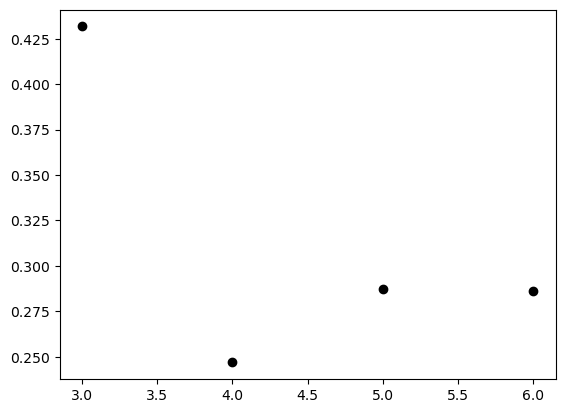

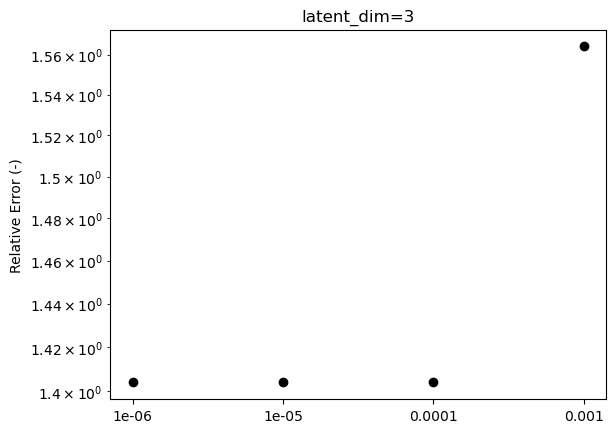

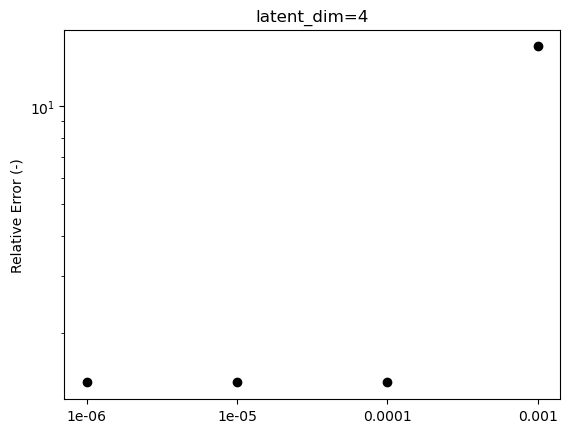

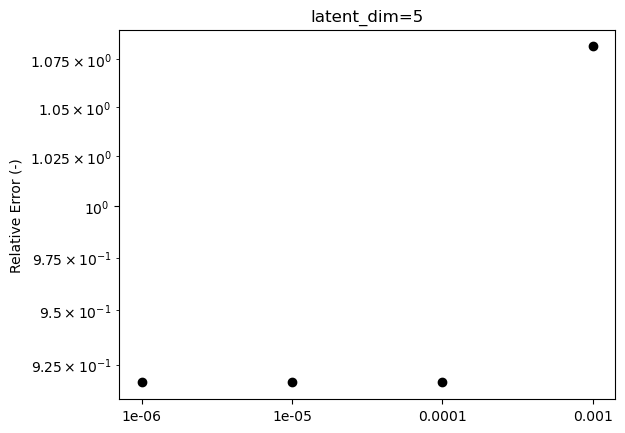

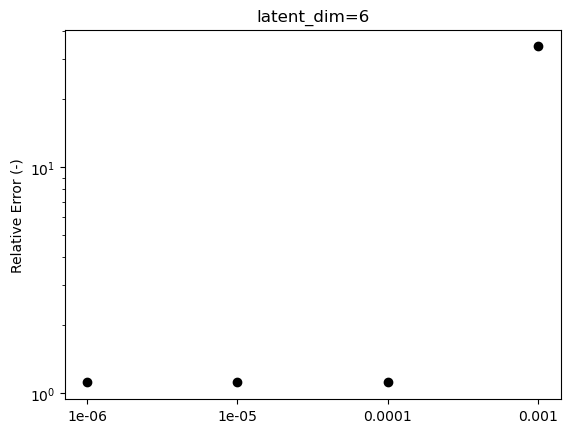

In [21]:
fig_recon, ax_recon = plt.subplots(1, 1)
for latent_dim in [3, 4, 5, 6]:
    print(f"Fitting latent_dim={latent_dim}")

    # Set seeds for reproducibility
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    driver = model_driver.sindy_shred_driver(
        latent_dim=latent_dim,
        poly_order=poly_order,
        verbose=False,
        num_epochs=1000,
        threshold=0.01,
        sample_mode="forecast",
    )
    driver.fit(
        num_sensors,
        dt,
        load_X,
        lags,
        train_length,
        validate_length,
        sensor_locations,
        test_length=test_length,
        seed=seed,
    )

    train_recons = driver._scaler.inverse_transform(
        driver._shred(driver._train_data.X).detach().cpu().numpy()
    )
    train_ground_truth = driver._scaler.inverse_transform(
        driver._train_data.Y.detach().cpu().numpy()
    )
    ax_recon.scatter(
        latent_dim,
        relative_error(train_recons, train_ground_truth),
        color="k",
        marker="o",
    )

    plt.figure()
    time_results = ds_obs.time.values[t_ind]
    driver._verbose = False
    for n_thresh, threshold in enumerate([10**-6, 10**-5, 10**-4, 10**-3]):
        driver.sindy_identify(threshold=threshold, plot_result=False)

        driver.sindy_simulate(driver._gru_outs)
        output_sindy_np = driver.shred_decode(driver._x_sim)
        output_sindy_np = driver._scaler.inverse_transform(output_sindy_np).mean(axis=1)
        t = time_results[lags - 1 : train_length + lags - 2]
        ds_gt = enso_box_extract(ds_scale, enso34_box).mean(
            dim=["latitude", "longitude"]
        )
        ds_gt = ds_gt.isel(time=slice(lags - 1, train_length + lags - 2))

        plt.scatter(
            n_thresh,
            relative_error(output_sindy_np, ds_gt.values),
            color="k",
            marker="o",
        )
    plt.gca().set_xticks(range(len([10**-6, 10**-5, 10**-4, 10**-3])))
    plt.gca().set_xticklabels([10**-6, 10**-5, 10**-4, 10**-3])
    plt.title(f"latent_dim={latent_dim}")
    plt.ylabel("Relative Error (-)")
    plt.gca().set_yscale("log")

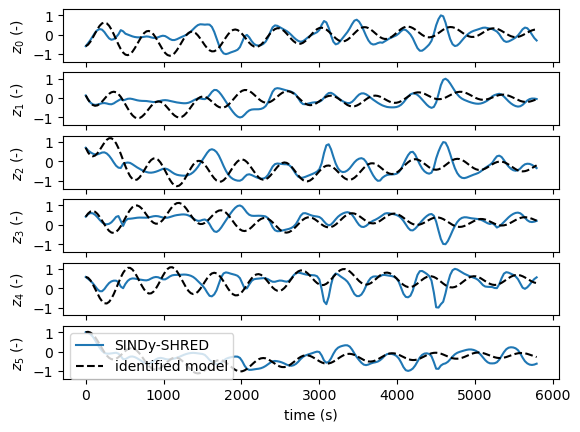

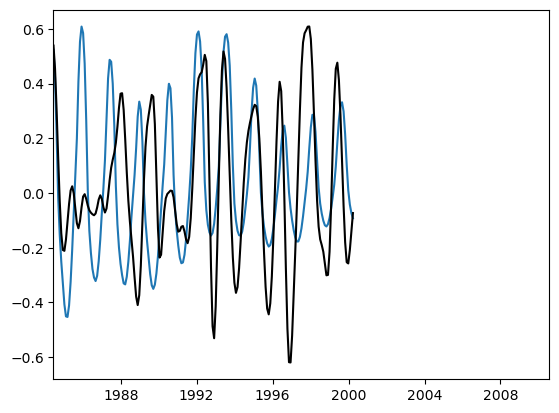

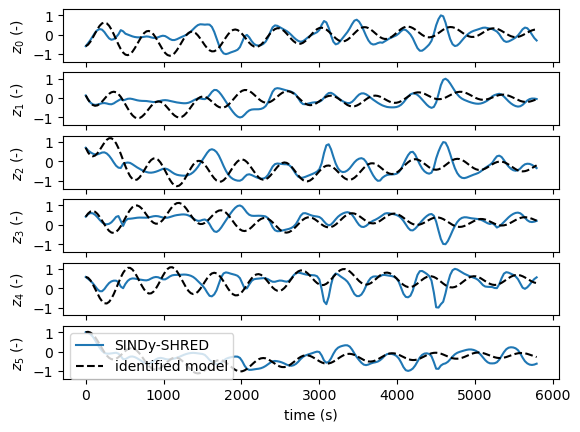

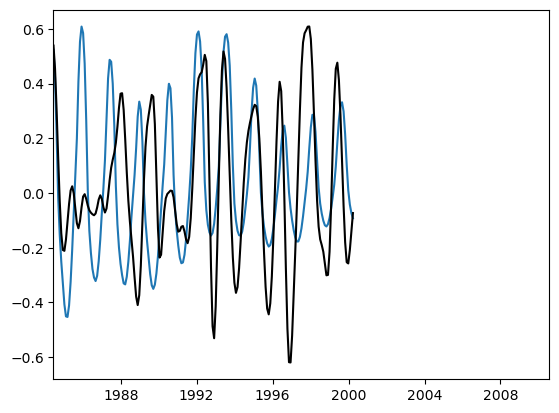

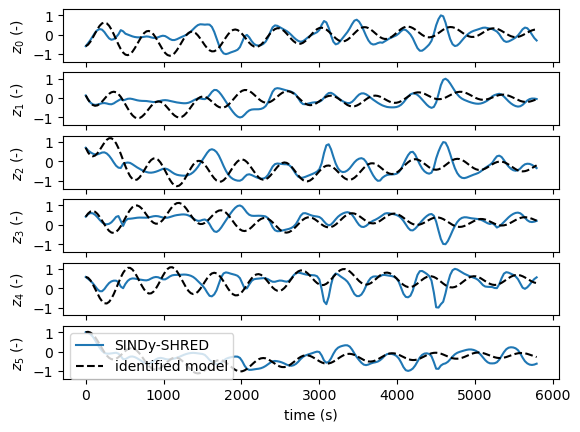

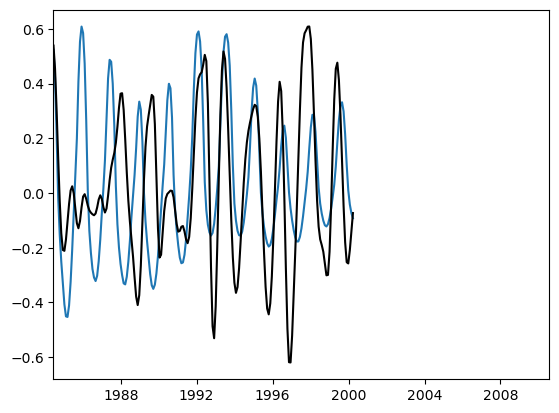

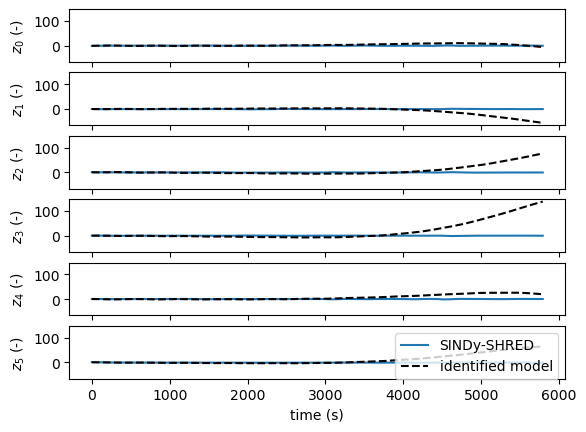

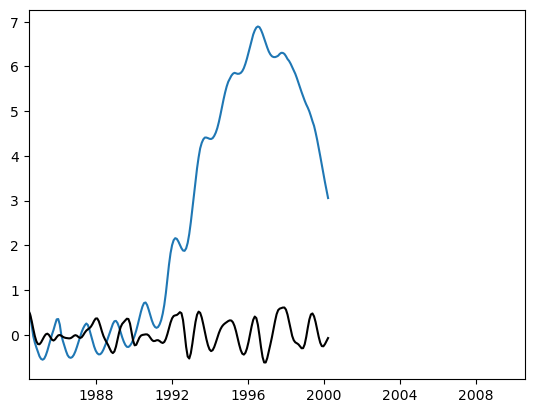

In [22]:
time_results = ds_obs.time.values[t_ind]


for n_thresh, threshold in enumerate([10**-6, 10**-5, 10**-4, 10**-3]):
    driver.sindy_identify(threshold=threshold, plot_result=True)
    # plt.gcf().suptitle(f"latent space for {modes_to_fit} mode")
    # plt.gcf().tight_layout()

    driver.sindy_simulate(driver._gru_outs)
    output_sindy_np = driver.shred_decode(driver._x_sim)
    output_sindy_np = driver._scaler.inverse_transform(output_sindy_np).mean(axis=1)
    t = time_results[lags - 1 : train_length + lags - 2]
    ds_gt = enso_box_extract(ds_scale, enso34_box).mean(dim=["latitude", "longitude"])
    ds_gt = ds_gt.isel(time=slice(lags - 1, train_length + lags - 2))

    plt.figure()
    plt.plot(t, output_sindy_np)
    plt.plot(
        ds_gt.time,
        ds_gt,
        color="k",
        label="ENSO34 Index",
    )

    plt.xlim(
        time_results[lags],
        time_results[train_length + validate_length + test_length + lags],
    )

1 : tensor(6.7437, device='mps:0', grad_fn=<AddBackward0>)
2 : tensor(1.4236, device='mps:0', grad_fn=<AddBackward0>)
3 : tensor(0.9565, device='mps:0', grad_fn=<AddBackward0>)
4 : tensor(0.6381, device='mps:0', grad_fn=<AddBackward0>)
5 : tensor(0.5725, device='mps:0', grad_fn=<AddBackward0>)
6 : tensor(0.5033, device='mps:0', grad_fn=<AddBackward0>)
7 : tensor(0.4023, device='mps:0', grad_fn=<AddBackward0>)
8 : tensor(0.3052, device='mps:0', grad_fn=<AddBackward0>)
9 : tensor(0.2283, device='mps:0', grad_fn=<AddBackward0>)
10 : tensor(0.2010, device='mps:0', grad_fn=<AddBackward0>)
11 : tensor(0.1746, device='mps:0', grad_fn=<AddBackward0>)
12 : tensor(0.1557, device='mps:0', grad_fn=<AddBackward0>)
13 : tensor(0.1385, device='mps:0', grad_fn=<AddBackward0>)
14 : tensor(0.1276, device='mps:0', grad_fn=<AddBackward0>)
15 : tensor(0.1186, device='mps:0', grad_fn=<AddBackward0>)
16 : tensor(0.1055, device='mps:0', grad_fn=<AddBackward0>)
17 : tensor(0.0980, device='mps:0', grad_fn=<AddB

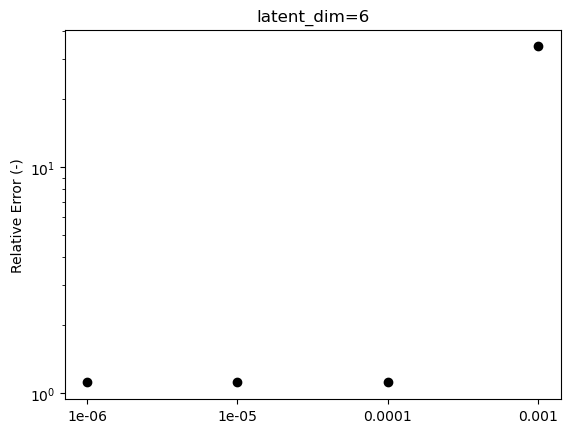

In [23]:
latent_dim = 6

# Set seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


driver = model_driver.sindy_shred_driver(
    latent_dim=latent_dim,
    poly_order=poly_order,
    verbose=True,
    num_epochs=1000,
    threshold=0.01,
    sample_mode="forecast",
)
driver.fit(
    num_sensors,
    dt,
    load_X,
    lags,
    train_length,
    validate_length,
    sensor_locations,
    test_length=test_length,
    seed=seed,
)

plt.figure()
time_results = ds_obs.time.values[t_ind]
driver._verbose = False
for n_thresh, threshold in enumerate([10**-6, 10**-5, 10**-4, 10**-3]):
    driver.sindy_identify(threshold=threshold, plot_result=False)

    driver.sindy_simulate(driver._gru_outs)
    output_sindy_np = driver.shred_decode(driver._x_sim)
    output_sindy_np = driver._scaler.inverse_transform(output_sindy_np).mean(axis=1)
    t = time_results[lags - 1 : train_length + lags - 2]
    ds_gt = enso_box_extract(ds_scale, enso34_box).mean(dim=["latitude", "longitude"])
    ds_gt = ds_gt.isel(time=slice(lags - 1, train_length + lags - 2))

    plt.scatter(
        n_thresh, relative_error(output_sindy_np, ds_gt.values), color="k", marker="o"
    )
plt.gca().set_xticks(range(len([10**-6, 10**-5, 10**-4, 10**-3])))
plt.gca().set_xticklabels([10**-6, 10**-5, 10**-4, 10**-3])
plt.title(f"latent_dim={latent_dim}")
plt.ylabel("Relative Error (-)")
plt.gca().set_yscale("log")

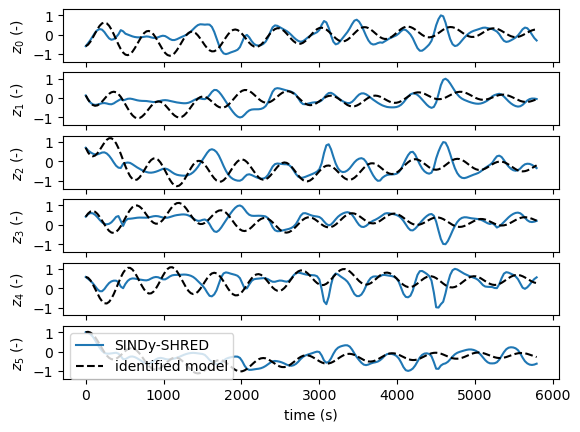

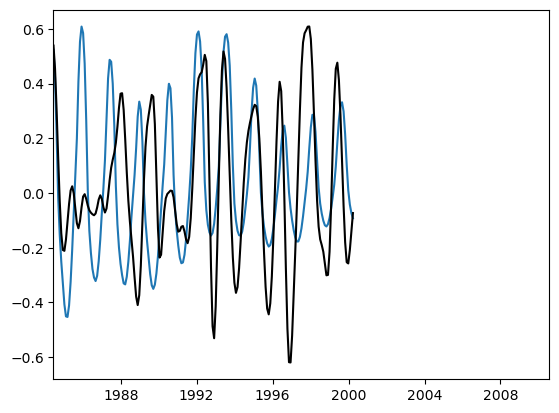

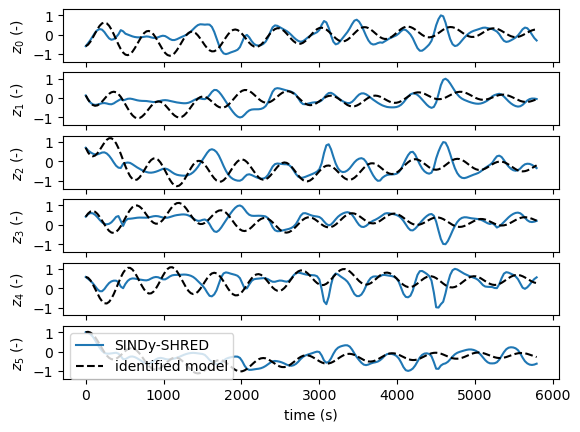

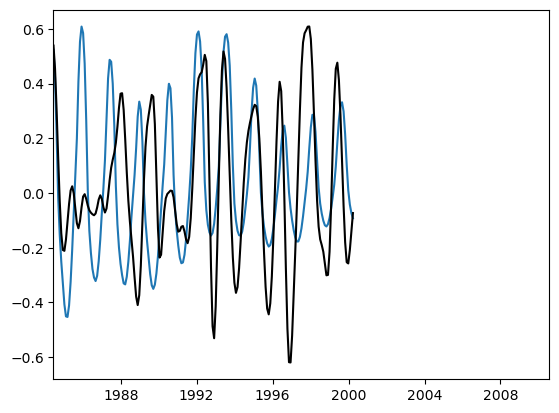

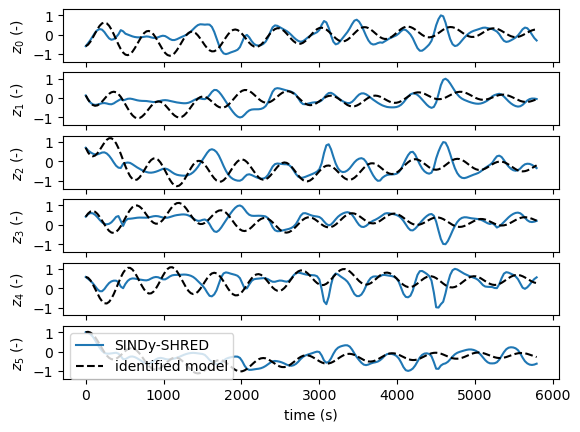

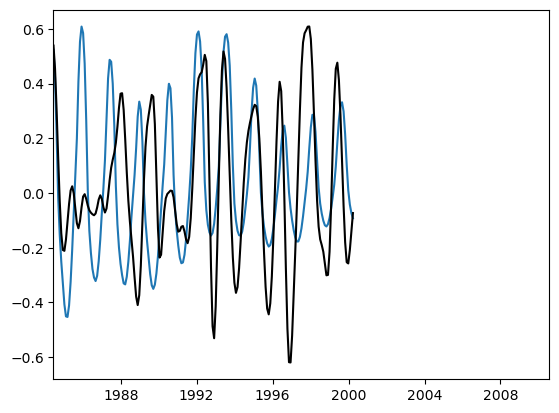

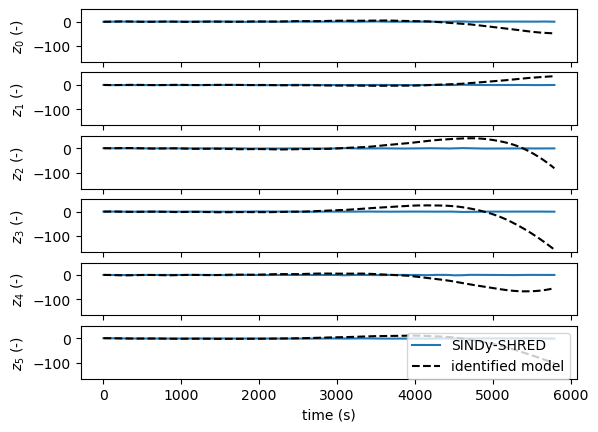

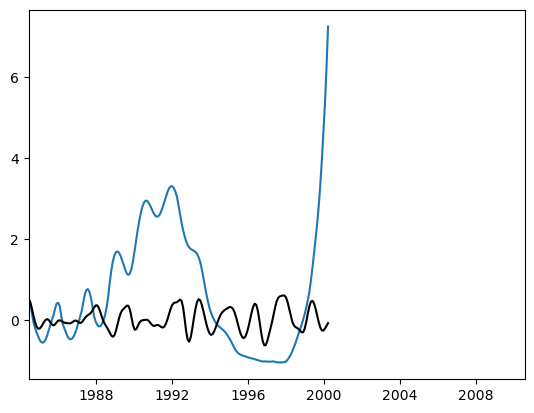

In [29]:
time_results = ds_obs.time.values[t_ind]


for n_thresh, threshold in enumerate([10**-6, 10**-5, 10**-4, 10**-3]):
    driver.sindy_identify(threshold=threshold, plot_result=True)
    # plt.gcf().suptitle(f"latent space for {modes_to_fit} mode")
    # plt.gcf().tight_layout()

    driver.sindy_simulate(driver._gru_outs)
    output_sindy_np = driver.shred_decode(driver._x_sim)
    output_sindy_np = driver._scaler.inverse_transform(output_sindy_np).mean(axis=1)
    t = time_results[lags - 1 : train_length + lags - 2]
    ds_gt = enso_box_extract(ds_scale, enso34_box).mean(dim=["latitude", "longitude"])
    ds_gt = ds_gt.isel(time=slice(lags - 1, train_length + lags - 2))

    plt.figure()
    plt.plot(t, output_sindy_np)
    plt.plot(
        ds_gt.time,
        ds_gt,
        color="k",
        label="ENSO34 Index",
    )

    plt.xlim(
        time_results[lags],
        time_results[train_length + validate_length + test_length + lags],
    )

## Compare in ENSO34 Box

In [25]:
train_recons = driver._scaler.inverse_transform(
    driver._shred(driver._train_data.X).detach().cpu().numpy()
)
train_ground_truth = driver._scaler.inverse_transform(
    driver._train_data.Y.detach().cpu().numpy()
)

val_recons = driver._scaler.inverse_transform(
    driver._shred(driver._valid_data.X).detach().cpu().numpy()
)
val_ground_truth = driver._scaler.inverse_transform(
    driver._valid_data.Y.detach().cpu().numpy()
)

test_recons = driver._scaler.inverse_transform(
    driver._shred(driver._test_data.X).detach().cpu().numpy()
)
test_ground_truth = driver._scaler.inverse_transform(
    driver._test_data.Y.detach().cpu().numpy()
)

In [26]:
if modes_to_fit == "ONI":

    time_results = ds_oni.time.values[t_ind]

    plt.figure(figsize=(10, 4))

    # Train
    ds_results = xarray_unstacked(
        train_recons.T,
        time_results[lags : train_length + lags],
        lon_ragged_oni,
        lat_ragged_oni,
    )
    enso_component = enso_box_extract(ds_results, enso34_box)
    enso_spatial_mean = enso_component.mean(dim=["longitude", "latitude"])
    plt.plot(
        time_results[lags - 1 : train_length + lags - 1],
        # enso_spatial_mean - enso_spatial_mean.mean(dim="time"),
        enso_spatial_mean,
        color="xkcd:blue",
        label="fit",
    )

    # Validate
    t = time_results[
        lags + train_length - 1 : lags + train_length + validate_length - 1
    ]

    ds_results = xarray_unstacked(
        val_recons.T,
        t,
        lon_ragged_oni,
        lat_ragged_oni,
    )
    enso_component = enso_box_extract(ds_results, enso34_box)
    enso_spatial_mean = enso_component.mean(dim=["longitude", "latitude"])
    plt.plot(
        t,
        # enso_spatial_mean - enso_spatial_mean.mean(dim="time"),
        enso_spatial_mean,
        color="xkcd:blue",
        ls="--",
    )

    # Test
    t = time_results[
        lags
        + train_length
        + validate_length
        - 2 : lags
        + train_length
        + validate_length
        + test_length
        - 2
    ]
    ds_results = xarray_unstacked(
        test_recons.T,
        t,
        lon_ragged_oni,
        lat_ragged_oni,
    )
    enso_component = enso_box_extract(ds_results, enso34_box)
    enso_spatial_mean = enso_component.mean(dim=["longitude", "latitude"])
    plt.plot(
        t,
        # enso_spatial_mean - enso_spatial_mean.mean(dim="time"),
        enso_spatial_mean,
        color="xkcd:blue",
        ls=":",
    )

    # Observations
    ds_gt = background_anomaly
    plt.plot(ds_gt.time, ds_gt, color="k", label="ENSO34 Index")

    plt.xlim(
        time_results[lags],
        time_results[train_length + validate_length + test_length + lags],
    )
    plt.xlim(time_results[lags], None)
    plt.legend(ncols=3)
    plt.ylabel("ENSO 34 box anomaly ($^{\circ}C$)")
    plt.gca().axvline(time_results[test_length + lags], ls="--", color="0.5")
    plt.gca().axvline(
        time_results[test_length + validate_length + lags], ls="--", color="0.5"
    )
    plt.title(f"fit {modes_to_fit} data\n Comparison in ENSO34 box")

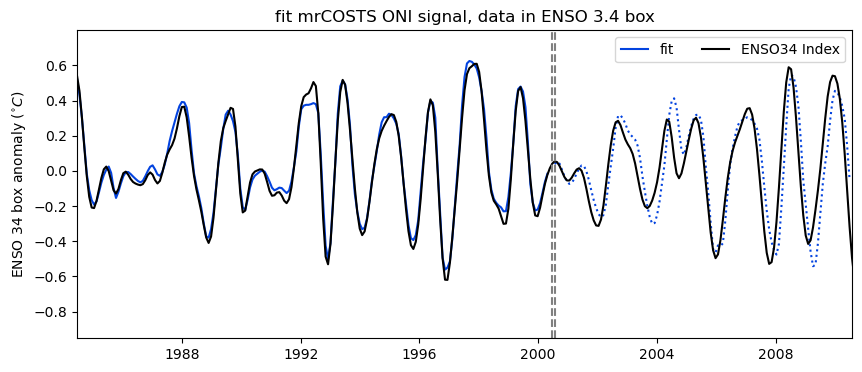

In [49]:
if box == "enso3.4":
    ragged_lon = lon_ragged_oni
    ragged_lat = lat_ragged_oni
    title = "data in ENSO 3.4 box"
else:
    ragged_lon = longitudes_ragged
    ragged_lat = latitudes_ragged
    title = "data in entire Pacific"

if modes_to_fit == "ENSO":

    time_results = ds_obs.time.values[t_ind]

    # (
    #     ds_sep.where((ds_sep.bands > 1) & (ds_sep.bands < 2), drop=True)
    #     .sum(dim="bands")
    #     .values[t_ind]
    # )

    plt.figure(figsize=(10, 4))

    # Train
    ds_results = xarray_unstacked(
        train_recons.T,
        time_results[lags : train_length + lags],
        ragged_lon,
        ragged_lat,
    )
    enso_component = enso_box_extract(ds_results, enso34_box)
    enso_spatial_mean = enso_component.mean(dim=["longitude", "latitude"])
    plt.plot(
        time_results[lags - 1 : train_length + lags - 1],
        # enso_spatial_mean - enso_spatial_mean.mean(dim="time"),
        enso_spatial_mean,
        color="xkcd:blue",
        label="fit",
    )

    # Validate
    t = time_results[
        lags + train_length - 1 : lags + train_length + validate_length - 1
    ]

    ds_results = xarray_unstacked(
        val_recons.T,
        t,
        ragged_lon,
        ragged_lat,
    )
    enso_component = enso_box_extract(ds_results, enso34_box)
    enso_spatial_mean = enso_component.mean(dim=["longitude", "latitude"])
    plt.plot(
        t,
        # enso_spatial_mean - enso_spatial_mean.mean(dim="time"),
        enso_spatial_mean,
        color="xkcd:blue",
        ls="--",
    )

    # Test
    t = time_results[
        lags
        + train_length
        + validate_length : lags
        # - 2 : lags
        + train_length
        + validate_length
        + test_length
        # - 2
    ]
    ds_results = xarray_unstacked(
        test_recons.T,
        t,
        ragged_lon,
        ragged_lat,
    )
    enso_component = enso_box_extract(ds_results, enso34_box)
    enso_spatial_mean = enso_component.mean(dim=["longitude", "latitude"])
    plt.plot(
        t,
        # enso_spatial_mean - enso_spatial_mean.mean(dim="time"),
        enso_spatial_mean,
        color="xkcd:blue",
        ls=":",
    )

    # Observations
    ds_gt = enso_box_extract(ds_scale, enso34_box).mean(dim=["latitude", "longitude"])
    plt.plot(
        ds_scale.time,
        ds_gt,
        color="k",
        label="ENSO34 Index",
    )

    plt.xlim(
        time_results[lags],
        time_results[train_length + validate_length + test_length + lags],
    )
    plt.xlim(time_results[lags], None)
    plt.legend(ncols=3)
    plt.ylabel("ENSO 34 box anomaly ($^{\circ}C$)")
    plt.gca().axvline(time_results[train_length + lags], ls="--", color="0.5")
    plt.gca().axvline(
        time_results[train_length + validate_length + lags], ls="--", color="0.5"
    )
    plt.title(f"fit mrCOSTS ONI signal, {title}")

Evaluate the reconstruction

0.7159604091379925


Text(0.5, 1.0, 'Test Period vs Observations. Test start = 2000-07-23, Test end = 2010-07-01')

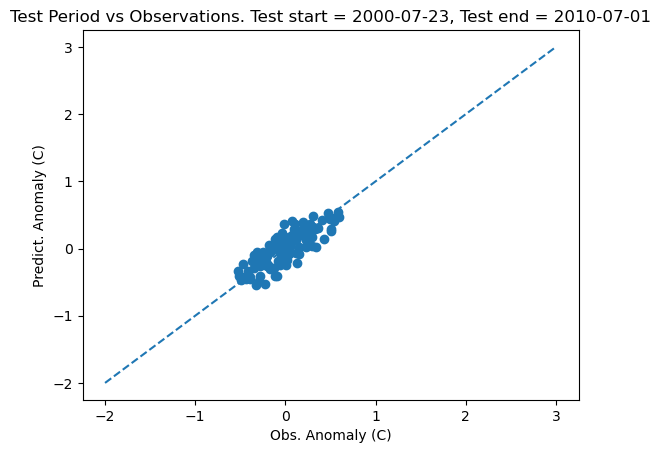

In [28]:
plt.scatter(
    ds_gt.sel(time=slice(ds_results.time[0], ds_results.time[-1])),
    ds_results.mean(dim=["latitude", "longitude"]),
)
plt.plot([-2, 3], [-2, 3], ls="--")
plt.ylabel("Predict. Anomaly (C)")
plt.xlabel("Obs. Anomaly (C)")

r = scipy.stats.pearsonr(
    ds_gt.sel(time=slice(ds_results.time[0], ds_results.time[-1])),
    ds_results.mean(dim=["latitude", "longitude"]),
)
print(r.correlation**2)
dt_start = pd.Timestamp(ds_results.time[0].values).strftime("%Y-%m-%d")
dt_end = pd.Timestamp(ds_results.time[-1].values).strftime("%Y-%m-%d")
plt.title(
    f"Test Period vs Observations. Test start = {dt_start}, Test end = {dt_end}"
)

# Predict

## Check latent space

### First the normalization of the latent space

In [35]:
threshold = 10**-8
g_train, _ = driver._shred.gru_outputs(driver._train_data.X, sindy=True)
x = g_train.detach().cpu().numpy()
model = ps.SINDy(
    optimizer=ps.STLSQ(threshold=threshold, alpha=0.05),
    differentiation_method=driver._differentiation_method,
    feature_library=ps.PolynomialLibrary(degree=driver._poly_order),
)

model.fit(x, t=driver._dt, ensemble=True);

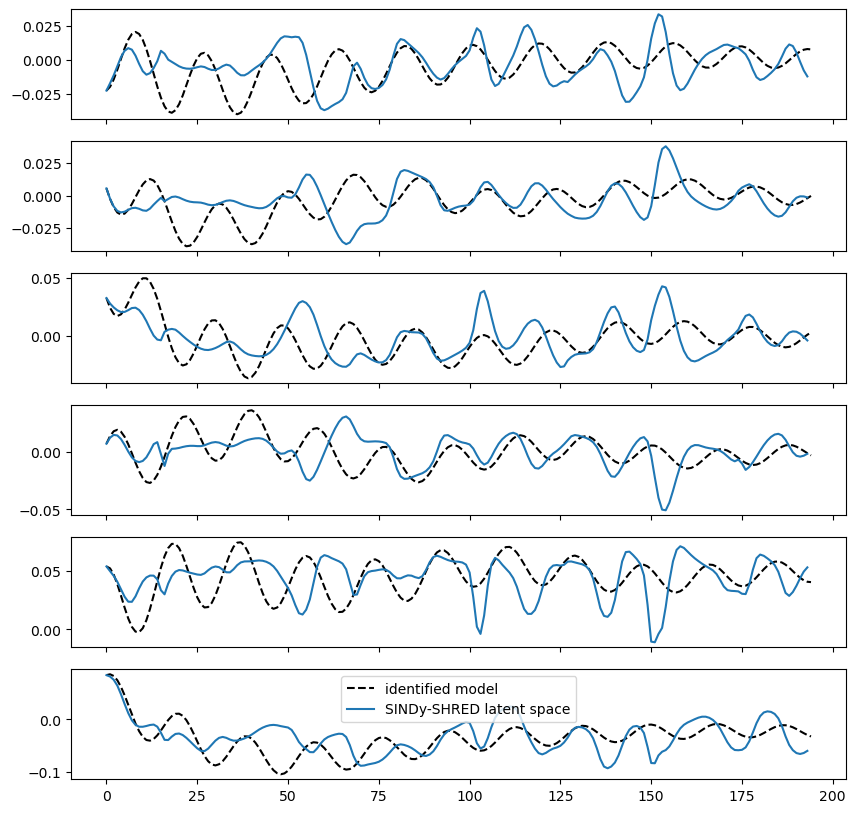

In [36]:
# Forward simulation with the discovered SINDy model
t_train = np.arange(0, 365 * num_train_years, dt)
init_cond = np.zeros(driver._latent_dim)
g_train, _ = driver._shred.gru_outputs(driver._train_data.X, sindy=True)
g_train = g_train[:, 0, :].detach().cpu().numpy()
init_cond[: driver._latent_dim] = np.atleast_2d(g_train[0])

x_sim_train = model.simulate(init_cond, t_train)
x_sim_train = np.array(x_sim_train)  # Ensure it's a numpy array if needed

fig, axes = plt.subplots(driver._latent_dim, 1, sharex=True, figsize=(10, 10))
for n in range(driver._latent_dim):
    ax = axes[n]
    ax.plot(x_sim_train[:, n], "k--", label="identified model")
    ax.plot(g_train[:, n], label="SINDy-SHRED latent space")
ax.legend()

(5281.0, 14821.0)

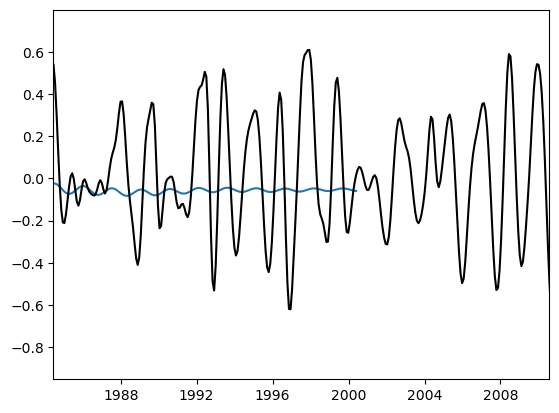

In [37]:
output_sindy_np = driver.shred_decode(x_sim_train)

t_train = time_results[lags : train_length + lags]

plt.plot(t_train, driver._scaler.inverse_transform(output_sindy_np).mean(axis=1))
ds_gt = enso_box_extract(ds_scale, enso34_box).mean(dim=["latitude", "longitude"])
plt.plot(
    ds_scale.time,
    ds_gt,
    color="k",
    label="mrCOSTS band",
)

plt.xlim(
    time_results[lags],
    time_results[train_length + validate_length + test_length + lags],
)

In [38]:
# # Step 1: Reverse Min-Max scaling for SINDy-simulated data (x_sim_test)
# x_sim_train = np.array(x_sim_train)  # Ensure it's a numpy array if needed

# # Revert the scaling from [-1, 1] back to [0, 1]
# # x_sim_train = (x_sim_train + 1) / 2

# gru_out_train, _ = driver._shred.gru_outputs(driver._train_data.X, sindy=True)
# gru_out_train = gru_out_train[:, 0, :]
# gru_out_train = gru_out_train.detach().cpu().numpy()

# # Perform the Min-Max reverse transformation using the original min/max values
# # for n in range(driver._latent_dim):  # Assuming 3 latent dimensions, need to be updated
# #     x_sim_train[:, n] = x_sim_train[:, n] * (
# #         np.max(gru_out_train[:, n]) - np.min(gru_out_train[:, n])
# #     ) + np.min(gru_out_train[:, n])

# # Perform the decoder reconstruction using the transformed SINDy-simulated data
# latent_pred_sindy = torch.FloatTensor(x_sim_train).to(
#     device
# )  # Convert to torch tensor for reconstruction

# # Pass the SINDy-simulated latent space data through the decoder
# decoder_model = driver._shred
# output_sindy = decoder_model.linear1(latent_pred_sindy)
# output_sindy = decoder_model.dropout(output_sindy)
# output_sindy = torch.nn.functional.relu(output_sindy)
# output_sindy = decoder_model.linear2(output_sindy)
# output_sindy = decoder_model.dropout(output_sindy)
# output_sindy = torch.nn.functional.relu(output_sindy)
# output_sindy = decoder_model.linear3(output_sindy)

# # Detach and convert the reconstructed data back to numpy for visualization
# output_sindy_np = output_sindy.detach().cpu().numpy()

In [39]:
# t_train = time_results[lags: train_length + lags]

# plt.plot(t_train, driver._scaler.inverse_transform(output_sindy_np).mean(axis=1))
# ds_gt = enso_box_extract(ds_scale, enso34_box).mean(dim=["latitude", "longitude"])
# plt.plot(
#     ds_scale.time,
#     ds_gt,
#     color="k",
#     label="mrCOSTS band",
# )

# plt.xlim(
#     time_results[lags],
#     time_results[train_length + validate_length + test_length + lags],
# )

In [40]:
tol_bright_reorder = [
    "#4477AA",
    "#CCBB44",
    "#EE6677",
    "#228833",
    "#66CCEE",
    "#AA3377",
    "#BBBBBB",
]

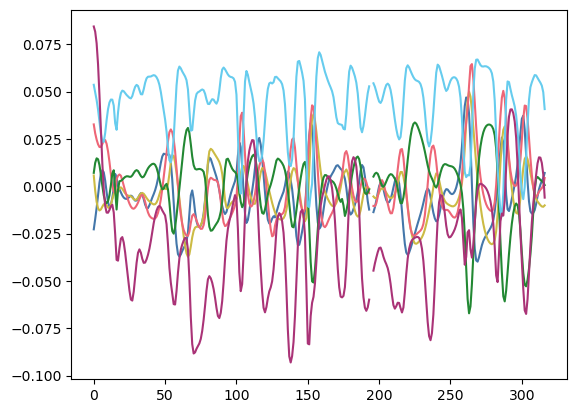

In [41]:
g_train, _ = driver._shred.gru_outputs(driver._train_data.X, sindy=True)

for l in range(driver._latent_dim):
    plt.plot(g_train[:, 0, l].detach().cpu().numpy(), color=tol_bright_reorder[l])

g_val, _ = driver._shred.gru_outputs(driver._valid_data.X, sindy=True)

for l in range(driver._latent_dim):
    plt.plot(
        np.arange(train_length, train_length + validate_length - 1),
        g_val[:, 0, l].detach().cpu().numpy(),
        color=tol_bright_reorder[l],
    )

g_test, _ = driver._shred.gru_outputs(driver._test_data.X, sindy=True)
for l in range(driver._latent_dim):
    plt.plot(
        np.arange(
            train_length + validate_length,
            train_length + validate_length + test_length - 1,
        ),
        g_test[:, 0, l].detach().cpu().numpy(),
        color=tol_bright_reorder[l],
    );

(-1.0, 1.0)

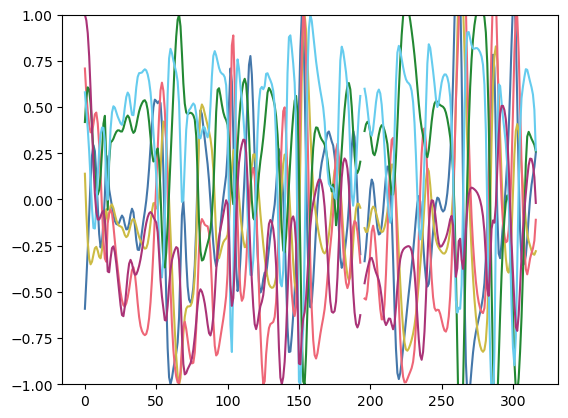

In [42]:
for l in range(driver._latent_dim):
    plt.plot(
        driver.gru_normalize(data_type="train").detach().cpu().numpy()[:, l],
        color=tol_bright_reorder[l],
    )
    plt.plot(
        np.arange(train_length, train_length + validate_length - 1),
        driver.gru_normalize(data_type="validate").detach().cpu().numpy()[:, l],
        marker=".",
        color=tol_bright_reorder[l],
    )

    plt.plot(
        np.arange(
            train_length + validate_length,
            train_length + validate_length + test_length - 1,
        ),
        driver.gru_normalize(data_type="test").detach().cpu().numpy()[:, l],
        color=tol_bright_reorder[l],
    )
plt.ylim(-1, 1)

The normalization is probably necessary (I trust Nathan and his cohort here). But, there is something whacky about the normalization that occurs that is worth looking into.

## Choose a model

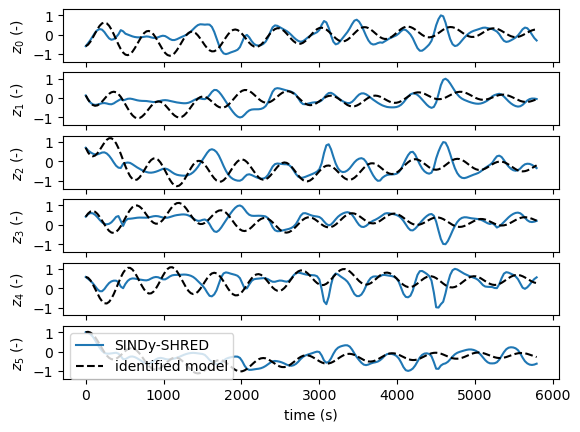

<Figure size 640x480 with 0 Axes>

In [43]:
# for threshold in [10**-6, 10**-5, 10**-4, 10**-3]:
driver._poly_order = 1
for threshold in [10**-6]:
    driver.sindy_identify(threshold=threshold, plot_result=True)
    plt.gcf().suptitle(f"latent space for {modes_to_fit} mode")
    plt.gcf().tight_layout()
    # plt.gcf().gca().set_ylim(-2, 2)

In [44]:
# Option 1: Simulate using the initial conditions from the first test time step
# gru_outs_test_np = driver.gru_normalize(data_type="test").detach().cpu().numpy()
# driver.sindy_simulate(gru_outs_test_np)
# x_sim_test = driver._x_sim

# Option 2: Simulate using the initial conditions from the last time step of the simulated latent space for the train split.
# driver.sindy_simulate(np.atleast_2d(driver._x_sim[-1]))
# x_sim_test = driver._x_sim

# # Plotting for each latent dimension: True vs SINDy
# fig, ax = plt.subplots(latent_dim, figsize=(10, latent_dim * 3))

# for i in range(latent_dim):
#     ax[i].plot(gru_outs_test_np[:, i], label="True Signal", linewidth=2)
#     ax[i].plot(x_sim_test[:, i], "k--", label="SINDy Approximation", linewidth=2)
#     ax[i].legend()
#     ax[i].set_ylabel(f"z_{i+1}")
#     ax[i].set_xlabel("Time")
#     ax[i].set_ylim(-1.5, 1.5)
# plt.tight_layout()
# plt.show()

In [57]:
# Forward simulation with the discovered SINDy model
t_test = np.arange(0, 365 * num_test_years, dt)
init_cond = np.zeros(driver._latent_dim)

# Option 1
gru_outs_test_np = driver.gru_normalize(data_type="test").detach().cpu().numpy()
init_cond[: driver._latent_dim] = gru_outs_test_np[0, :]

# Option 2
# init_cond[: driver._latent_dim] = np.atleast_2d(driver._x_sim[-1])

# Option 3 use last train latent space value
t_test = np.arange(-dt, 365 * num_test_years - dt, dt)
gru_outs_train_np = driver.gru_normalize(data_type="train").detach().cpu().numpy()
gru_outs_test_np = driver.gru_normalize(data_type="test").detach().cpu().numpy()
init_cond[: driver._latent_dim] = gru_outs_train_np[-1, :]

x_sim_test = driver._model.simulate(init_cond, t_test)
x_sim_test = np.array(x_sim_test)  # Ensure it's a numpy array if needed

(-1.5, 1.5)

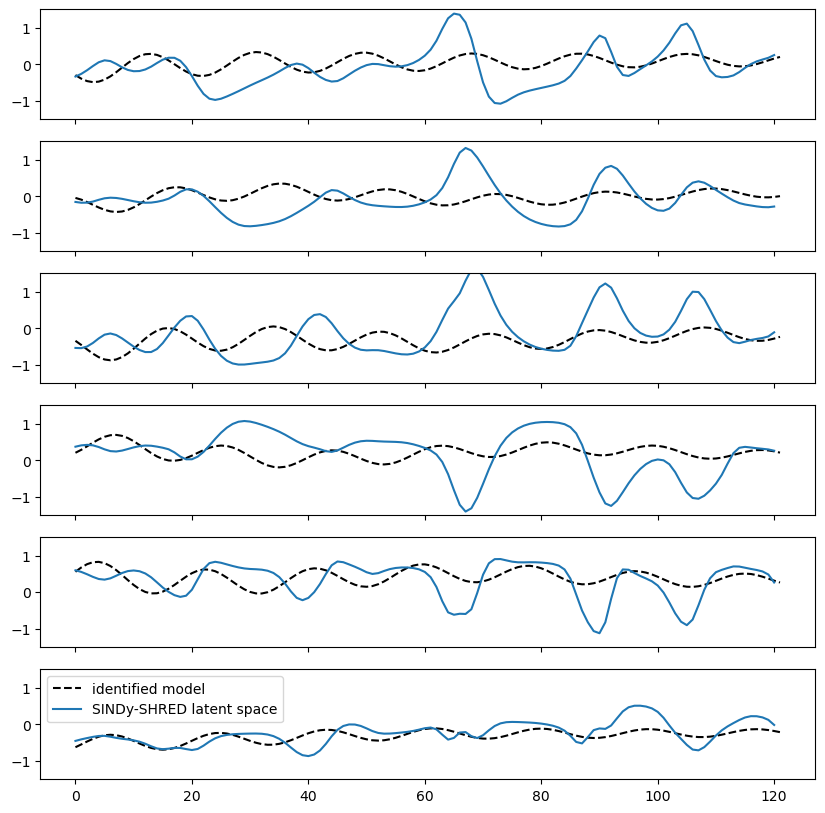

In [58]:
fig, axes = plt.subplots(
    driver._latent_dim, 1, sharex=True, sharey=True, figsize=(10, 10)
)
for n in range(driver._latent_dim):
    ax = axes[n]
    ax.plot(x_sim_test[:, n], "k--", label="identified model")
    ax.plot(gru_outs_test_np[:, n], label="SINDy-SHRED latent space")
ax.legend()
ax.set_ylim(-1.5, 1.5)

In [59]:
# # Forward simulation with the discovered SINDy model
# t_test = np.arange(0, 365 * num_test_years, dt)
# init_cond = np.zeros(driver._latent_dim)
# # init_cond[:latent_dim] = gru_outs_test_np[0, :]
# gru_outs_test_np = driver.gru_normalize(data_type="test").detach().cpu().numpy()
# init_cond[: driver._latent_dim] = gru_outs_test_np[0, :]

# x_sim_test = driver._model.simulate(init_cond, t_test)

# Step 1: Reverse Min-Max scaling for SINDy-simulated data (x_sim_test)
x_sim_test = np.array(x_sim_test)  # Ensure it's a numpy array if needed

# Revert the scaling from [-1, 1] back to [0, 1]
x_sim_test = (x_sim_test + 1) / 2

gru_out_train, _ = driver._shred.gru_outputs(driver._train_data.X, sindy=True)
gru_out_train = gru_out_train[:, 0, :]
gru_out_train = gru_out_train.detach().cpu().numpy()

# Perform the Min-Max reverse transformation using the original min/max values
for n in range(driver._latent_dim):  # Assuming 3 latent dimensions, need to be updated
    x_sim_test[:, n] = x_sim_test[:, n] * (
        np.max(gru_out_train[:, n]) - np.min(gru_out_train[:, n])
    ) + np.min(gru_out_train[:, n])

# Perform the decoder reconstruction using the transformed SINDy-simulated data
latent_pred_sindy = torch.FloatTensor(x_sim_test).to(
    device
)  # Convert to torch tensor for reconstruction

# Pass the SINDy-simulated latent space data through the decoder
decoder_model = driver._shred
output_sindy = decoder_model.linear1(latent_pred_sindy)
output_sindy = decoder_model.dropout(output_sindy)
output_sindy = torch.nn.functional.relu(output_sindy)
output_sindy = decoder_model.linear2(output_sindy)
output_sindy = decoder_model.dropout(output_sindy)
output_sindy = torch.nn.functional.relu(output_sindy)
output_sindy = decoder_model.linear3(output_sindy)

# Detach and convert the reconstructed data back to numpy for visualization
output_sindy_np = output_sindy.detach().cpu().numpy()

(5311.0, 14851.0)

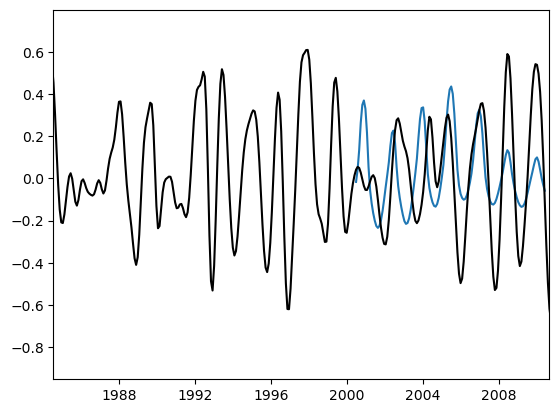

In [60]:
plt.plot(t, driver._scaler.inverse_transform(output_sindy_np).mean(axis=1))
ds_gt = enso_box_extract(ds_scale, enso34_box).mean(dim=["latitude", "longitude"])
plt.plot(
    ds_scale.time,
    ds_gt,
    color="k",
    label="ENSO34 Index",
)

plt.xlim(
    time_results[lags],
    time_results[train_length + validate_length + test_length + lags],
)

(-2.0, 2.0)

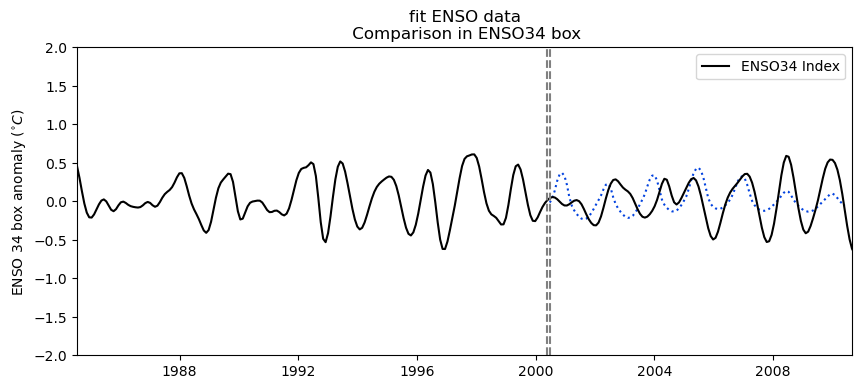

In [61]:
time_results = ds_oni.time.values[t_ind]

plt.figure(figsize=(10, 4))

# Test
t = time_results[
    lags
    + train_length
    + validate_length
    - 2 : lags
    + train_length
    + validate_length
    + test_length
    - 2
]

# plt.plot(t, driver._scaler.inverse_transform(output_sindy_np).mean(axis=1))


ds_results = xarray_unstacked(
    driver._scaler.inverse_transform(output_sindy_np).T,
    t,
    lon_ragged_oni,
    lat_ragged_oni,
)
enso_component = enso_box_extract(ds_results, enso34_box)
enso_spatial_mean = enso_component.mean(dim=["longitude", "latitude"])
plt.plot(
    t,
    enso_spatial_mean,
    color="xkcd:blue",
    ls=":",
)

# Observations
plt.plot(ds_gt.time, ds_gt, color="k", label="ENSO34 Index")

plt.xlim(
    time_results[lags],
    time_results[train_length + validate_length + test_length + lags],
)
plt.xlim(time_results[lags], None)
plt.legend(ncols=3)
plt.ylabel("ENSO 34 box anomaly ($^{\circ}C$)")
plt.gca().axvline(time_results[train_length + lags - 2], ls="--", color="0.5")
plt.gca().axvline(
    time_results[train_length + validate_length + lags - 2], ls="--", color="0.5"
)
plt.title(f"fit {modes_to_fit} data\n Comparison in ENSO34 box")
plt.gca().set_ylim(-2, 2)